# CIFAR-10 Image Classification using CNN and Transfer Learning

In [237]:
!pip install tensorflow

In [239]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

## 1. Dataset Loading

In [241]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

## 2. Data Exploration

In [242]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


<function matplotlib.pyplot.show(close=None, block=None)>

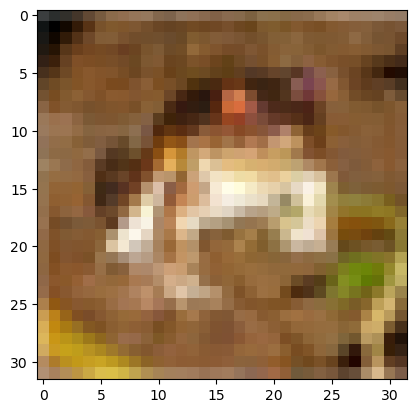

In [245]:
plt.imshow(x_train[0])
plt.show

In [247]:
print(x_train[0]) #numpy array

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [249]:
x_train[0]        # (32, 32, 3) → μια εικόνα
x_train[0][0]     # (32, 3) → πρώτη σειρά pixels
x_train[0][0][0]  # (3,) → ένα pixel = [R, G, B]

array([59, 62, 63], dtype=uint8)

## 3. Data Preprocessing

In [251]:
x_train = x_train / 255.0
x_test = x_test / 255.0 

In [252]:
print(y_train[0])

[6]


In [255]:
y_train.shape

(50000, 1)

In [257]:
y_train[0][0]

6

In [259]:
y_train[3][0]

4

In [261]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
label = y_train[3][0]
print(class_names[label])

deer


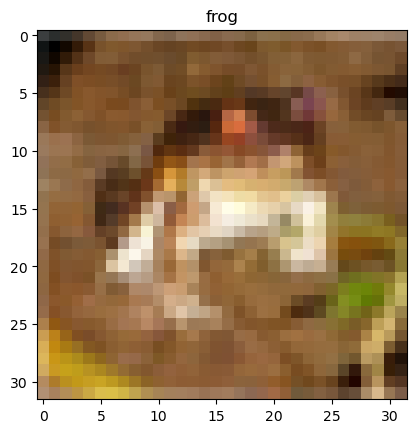

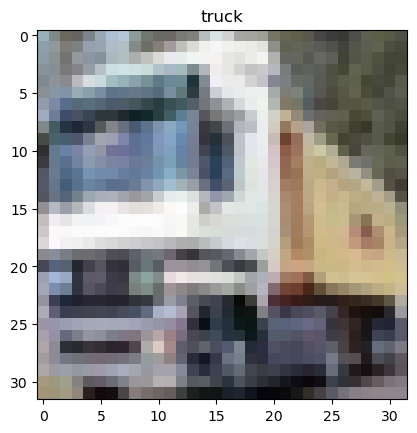

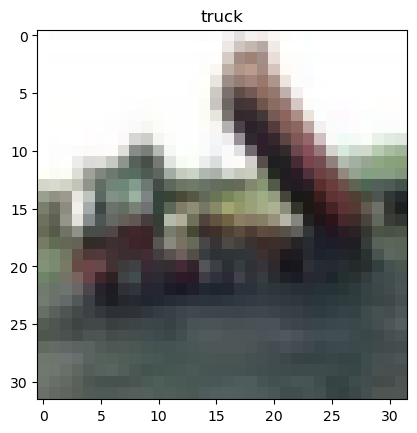

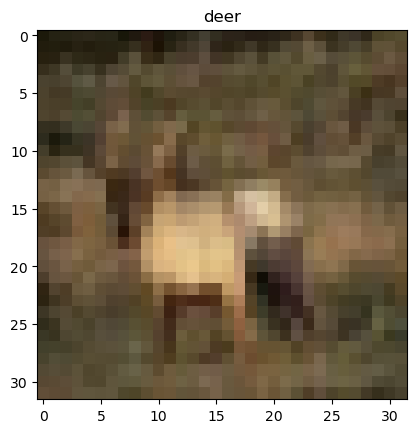

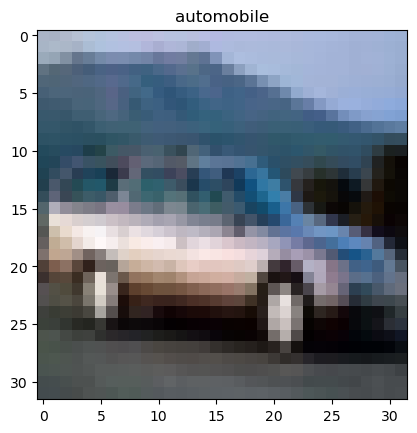

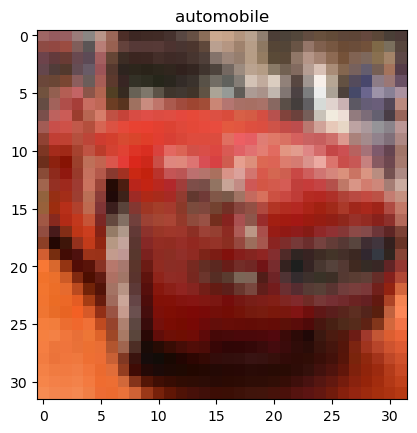

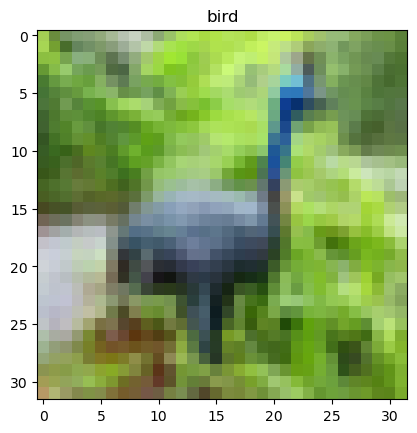

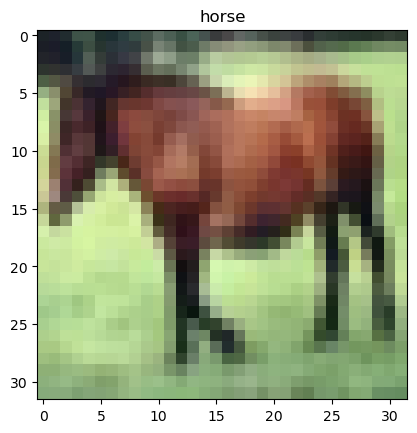

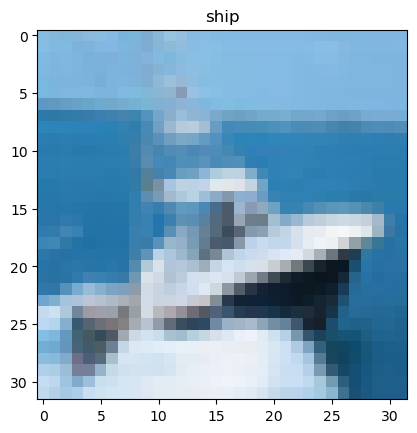

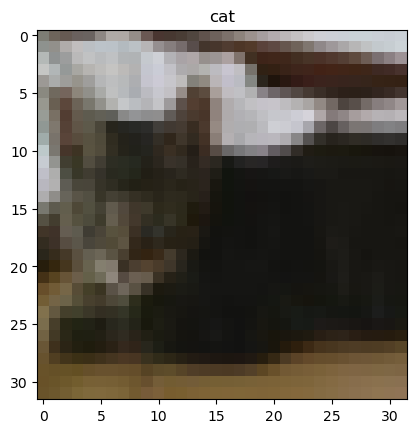

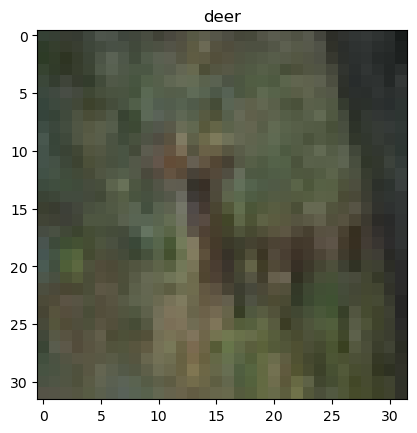

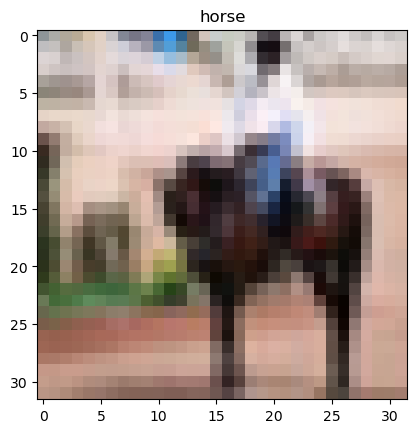

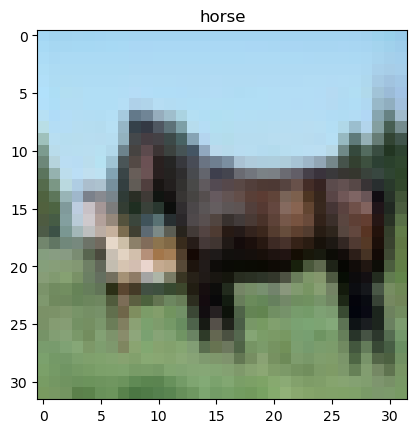

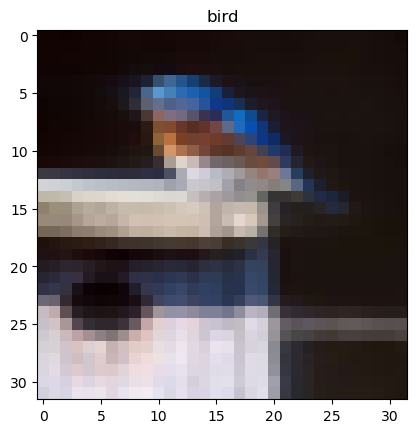

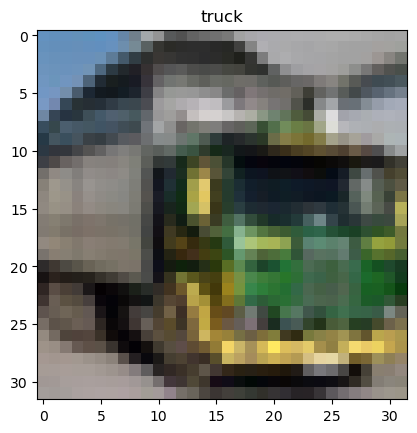

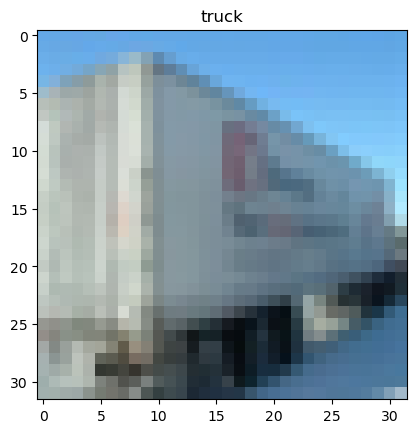

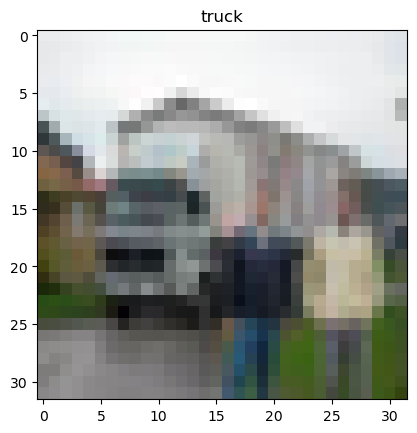

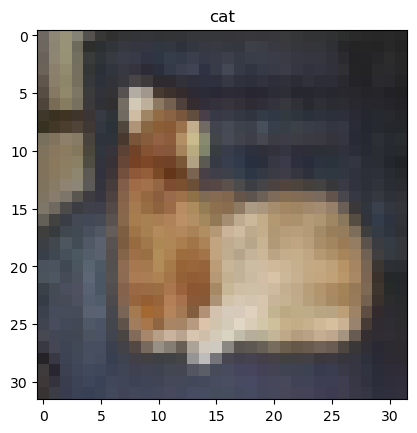

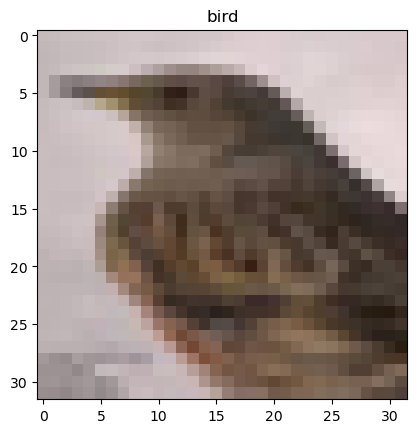

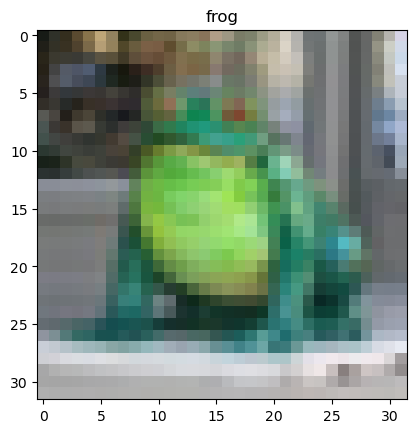

In [263]:
for i in range(20):
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.show()

In [264]:
x_train[0].shape

(32, 32, 3)

In [265]:
print(y_train.shape)

(50000, 1)


In [266]:
for i in range(3):
    print(y_train[i])

[6]
[9]
[9]


## 4. Baseline CNN

In [267]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

C:\Users\evang\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [268]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [275]:
# model.fit(x_train, y_train, epochs=5)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4530 - loss: 1.5212 - val_accuracy: 0.5604 - val_loss: 1.2547
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5900 - loss: 1.1678 - val_accuracy: 0.5984 - val_loss: 1.1475
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6357 - loss: 1.0435 - val_accuracy: 0.6346 - val_loss: 1.0534
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6652 - loss: 0.9633 - val_accuracy: 0.6252 - val_loss: 1.0750
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6878 - loss: 0.8998 - val_accuracy: 0.6667 - val_loss: 0.9675


In [276]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6679 - loss: 0.9634


[0.9633616209030151, 0.667900025844574]

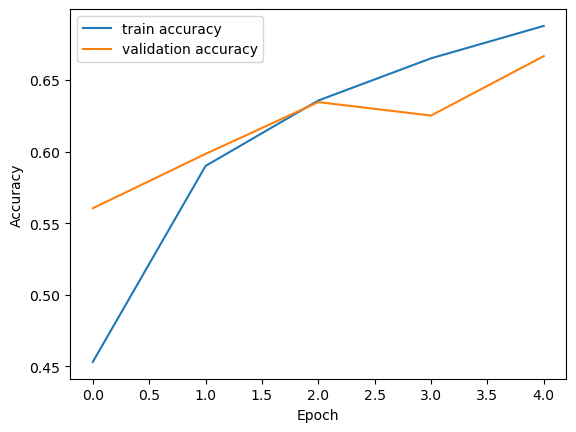

In [277]:
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

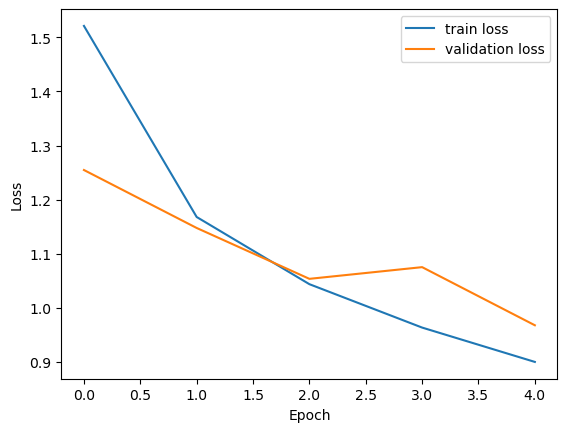

In [278]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [279]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

In [280]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [281]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3336 - loss: 1.8051 - val_accuracy: 0.4238 - val_loss: 1.5712
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4382 - loss: 1.5400 - val_accuracy: 0.4979 - val_loss: 1.3752
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4819 - loss: 1.4328 - val_accuracy: 0.5229 - val_loss: 1.3500
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5136 - loss: 1.3617 - val_accuracy: 0.5749 - val_loss: 1.2110
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5321 - loss: 1.3109 - val_accuracy: 0.5886 - val_loss: 1.1753


In [282]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5859 - loss: 1.1733


[1.1732704639434814, 0.5859000086784363]

In [283]:
predictions = model.predict(x_test) #"το μοντέλο τι πιστεύει ότι βλέπει;"

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [284]:
predictions.shape

(10000, 10)

In [286]:
predictions[0]

array([0.02594958, 0.00158675, 0.06061757, 0.57128257, 0.02164597,
       0.19320513, 0.04623955, 0.00498877, 0.07072286, 0.00376126],
      dtype=float32)

In [287]:
np.argmax(predictions[0]) #👉 ποιο class διάλεξε.

3

In [288]:
class_names[np.argmax(predictions[0])]

'cat'

In [289]:
np.max(predictions[0]) #👉 confidence του model.

0.57128257

## 6. Error Analysis

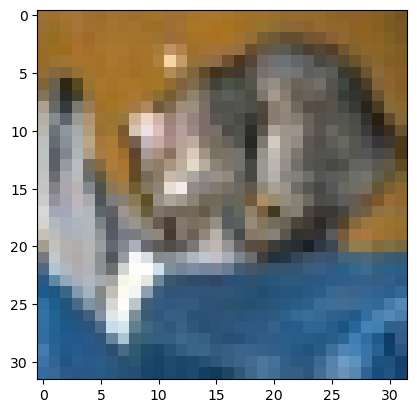

Real: cat
Predicted: cat


In [290]:
plt.imshow(x_test[0])
plt.show()

print("Real:", class_names[y_test[0][0]])
print("Predicted:", class_names[np.argmax(predictions[0])])

In [291]:
y_test.shape

(10000, 1)

In [292]:
predictions.shape

(10000, 10)

In [293]:
y_pred = np.argmax(predictions, axis=1) # axis=1 = σημαίνει: “βρες το μεγαλύτερο σε κάθε row”

In [294]:
print(y_pred[:10])

[3 8 8 8 6 6 1 6 3 1]


In [295]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

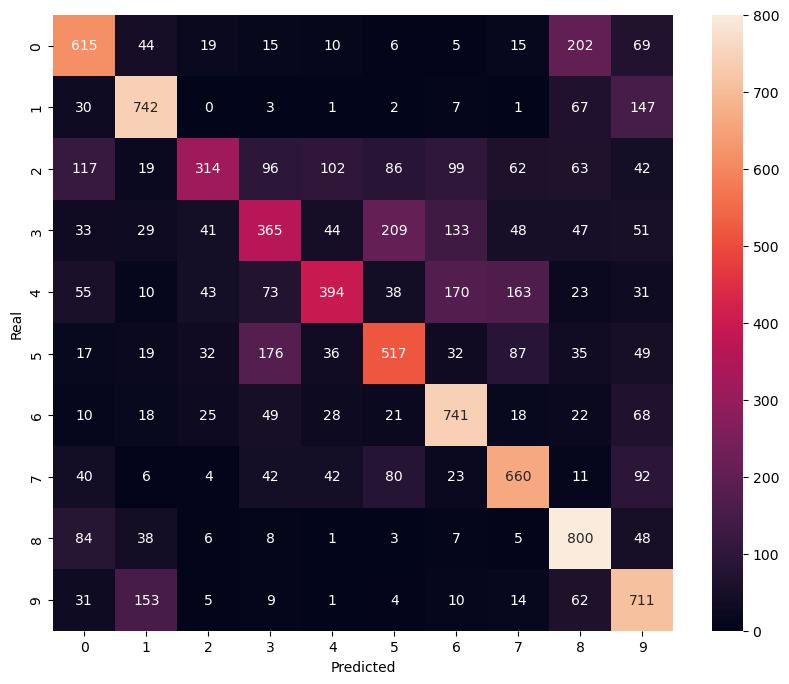

In [296]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

In [297]:
wrong = np.where(y_pred != y_test.flatten())[0]

In [298]:
print(wrong[:10])

[ 3 12 17 19 22 24 27 32 33 35]


In [299]:
print(len(wrong)) # 👉 το model έκανε λάθος σε 4058 εικόνες από: 10000

# Άρα σωστές: 10000 - 4058 = 5942

4141


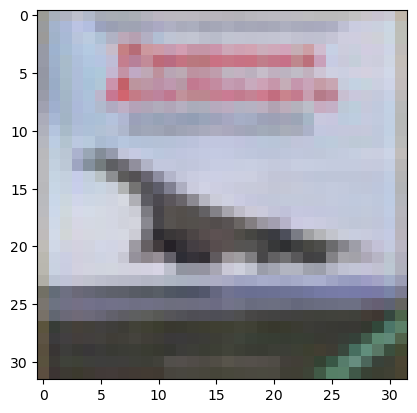

Real: airplane
Predicted: ship


In [300]:
i = wrong[0]

plt.imshow(x_test[i])
plt.show()

print("Real:", class_names[y_test[i][0]])
print("Predicted:", class_names[y_pred[i]])

In [301]:
model.save("cifar_cnn_model.keras")

In [302]:
from tensorflow.keras.models import load_model

loaded_model = load_model("cifar_cnn_model.keras")

In [303]:
loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5859 - loss: 1.1733


[1.1732704639434814, 0.5859000086784363]

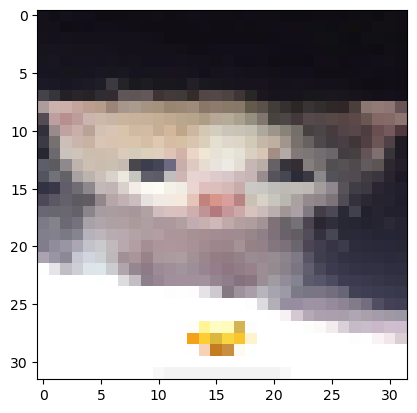

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted: ship
Confidence: 0.2606505


In [304]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img = load_img("animal_4.jpg", target_size=(32, 32))

plt.imshow(img)
plt.show()

img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = loaded_model.predict(img_array)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted:", class_names[predicted_class])
print("Confidence:", confidence)

In [306]:
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train)
y_test_onehot = to_categorical(y_test)

In [307]:
print(y_train[0])
print(y_train_onehot[0])

print(y_train[1])
print(y_train_onehot[1])

print(y_train[2])
print(y_train_onehot[2])

[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
[9]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[9]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [308]:
print(y_train_onehot[0])
print(y_train_onehot[0][6])

print(y_train_onehot[1][9])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
1.0
1.0


In [309]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [310]:
history = model.fit(
    x_train,
    y_train_onehot,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5500 - loss: 1.2668 - val_accuracy: 0.5833 - val_loss: 1.1818
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5626 - loss: 1.2329 - val_accuracy: 0.5909 - val_loss: 1.1470
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5734 - loss: 1.2075 - val_accuracy: 0.6109 - val_loss: 1.0973
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5792 - loss: 1.1869 - val_accuracy: 0.6180 - val_loss: 1.0745
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5882 - loss: 1.1608 - val_accuracy: 0.6213 - val_loss: 1.0707


In [311]:
model.evaluate(x_test, y_test_onehot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6178 - loss: 1.0758


[1.0757819414138794, 0.6177999973297119]

In [312]:
from tensorflow.keras import Input, Model
from tensorflow.keras import layers 

In [313]:
inputs = Input(shape=(32, 32, 3))

x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)

x = layers.Conv2D(32, (3, 3), activation="relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

# ΠΡΩΤΗ παρένθεση:
# ρυθμίσεις layer

# ΔΕΥΤΕΡΗ παρένθεση:
# σε ποια δεδομένα θα εφαρμοστεί

x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(10, activation="softmax")(x)

model_functional = Model(inputs=inputs, outputs=outputs)

In [314]:
model_functional.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [315]:
history_functional = model_functional.fit(
    x_train,
    y_train_onehot,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3325 - loss: 1.8162 - val_accuracy: 0.4366 - val_loss: 1.5711
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4417 - loss: 1.5395 - val_accuracy: 0.5192 - val_loss: 1.3330
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4767 - loss: 1.4465 - val_accuracy: 0.5362 - val_loss: 1.3087
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5062 - loss: 1.3762 - val_accuracy: 0.5698 - val_loss: 1.2180
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5235 - loss: 1.3291 - val_accuracy: 0.5527 - val_loss: 1.3020


In [316]:
model_functional.evaluate(x_test, y_test_onehot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5420 - loss: 1.2977


[1.2976763248443604, 0.5419999957084656]

In [317]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Input, Model, layers

## 7. Transfer Learning with MobileNetV2

In [318]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False # Αυτό σημαίνει: “μην αλλάξεις τις pretrained γνώσεις //// μην αλλάξεις αυτά που ήδη ξέρει το MobileNet

inputs = Input(shape=(32, 32, 3))
x = layers.Resizing(96, 96)(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

transfer_model = Model(inputs, outputs)

In [319]:
transfer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [320]:
history_transfer = transfer_model.fit(
    x_train,
    y_train_onehot,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 61ms/step - accuracy: 0.7477 - loss: 0.7249 - val_accuracy: 0.7878 - val_loss: 0.6183
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 73s 58ms/step - accuracy: 0.8034 - loss: 0.5593 - val_accuracy: 0.7852 - val_loss: 0.6136
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 58ms/step - accuracy: 0.8239 - loss: 0.5014 - val_accuracy: 0.8025 - val_loss: 0.5783
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 58ms/step - accuracy: 0.8389 - loss: 0.4548 - val_accuracy: 0.8064 - val_loss: 0.5644
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 58ms/step - accuracy: 0.8529 - loss: 0.4132 - val_accuracy: 0.8049 - val_loss: 0.5896


In [321]:
transfer_model.evaluate(x_test, y_test_onehot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8009 - loss: 0.6034


[0.6034419536590576, 0.8008999824523926]

## 8. Results and Conclusions

### Summary

Baseline CNN Accuracy: 66.7%

CNN + Augmentation Accuracy: 58.5%

MobileNetV2 Accuracy: 80.1%

Transfer learning significantly improved performance compared to the baseline CNN.